<a href="https://colab.research.google.com/github/Archin0/PCVK_Sem5/blob/main/Week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Persiapan Awal
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Definisi Fungsi Konvolusi Manual
def convolution2d(image, kernel, stride=1, padding=0):
    # Dapatkan dimensi
    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape

    # Tambahkan padding
    if padding > 0:
        image_padded = np.pad(image, pad_width=padding, mode='constant', constant_values=0)
    else:
        image_padded = image

    # Hitung dimensi output
    output_height = (image_height - kernel_height + 2 * padding) // stride + 1
    output_width = (image_width - kernel_width + 2 * padding) // stride + 1
    output = np.zeros((output_height, output_width))

    # Proses konvolusi
    for y in range(0, output_height):
        for x in range(0, output_width):
            # Ambil bagian citra yang akan dikonvolusi
            roi = image_padded[y * stride : y * stride + kernel_height, x * stride : x * stride + kernel_width]
            # Lakukan perkalian elemen-wise dan jumlahkan
            output[y, x] = np.sum(roi * kernel)

    return output

# Muat gambar dan ubah ke grayscale
img_female_path = '/content/drive/MyDrive/PCVK/female.jpg'
img_female = cv2.imread(img_female_path)
img_gray_female = cv2.cvtColor(img_female, cv2.COLOR_BGR2GRAY)

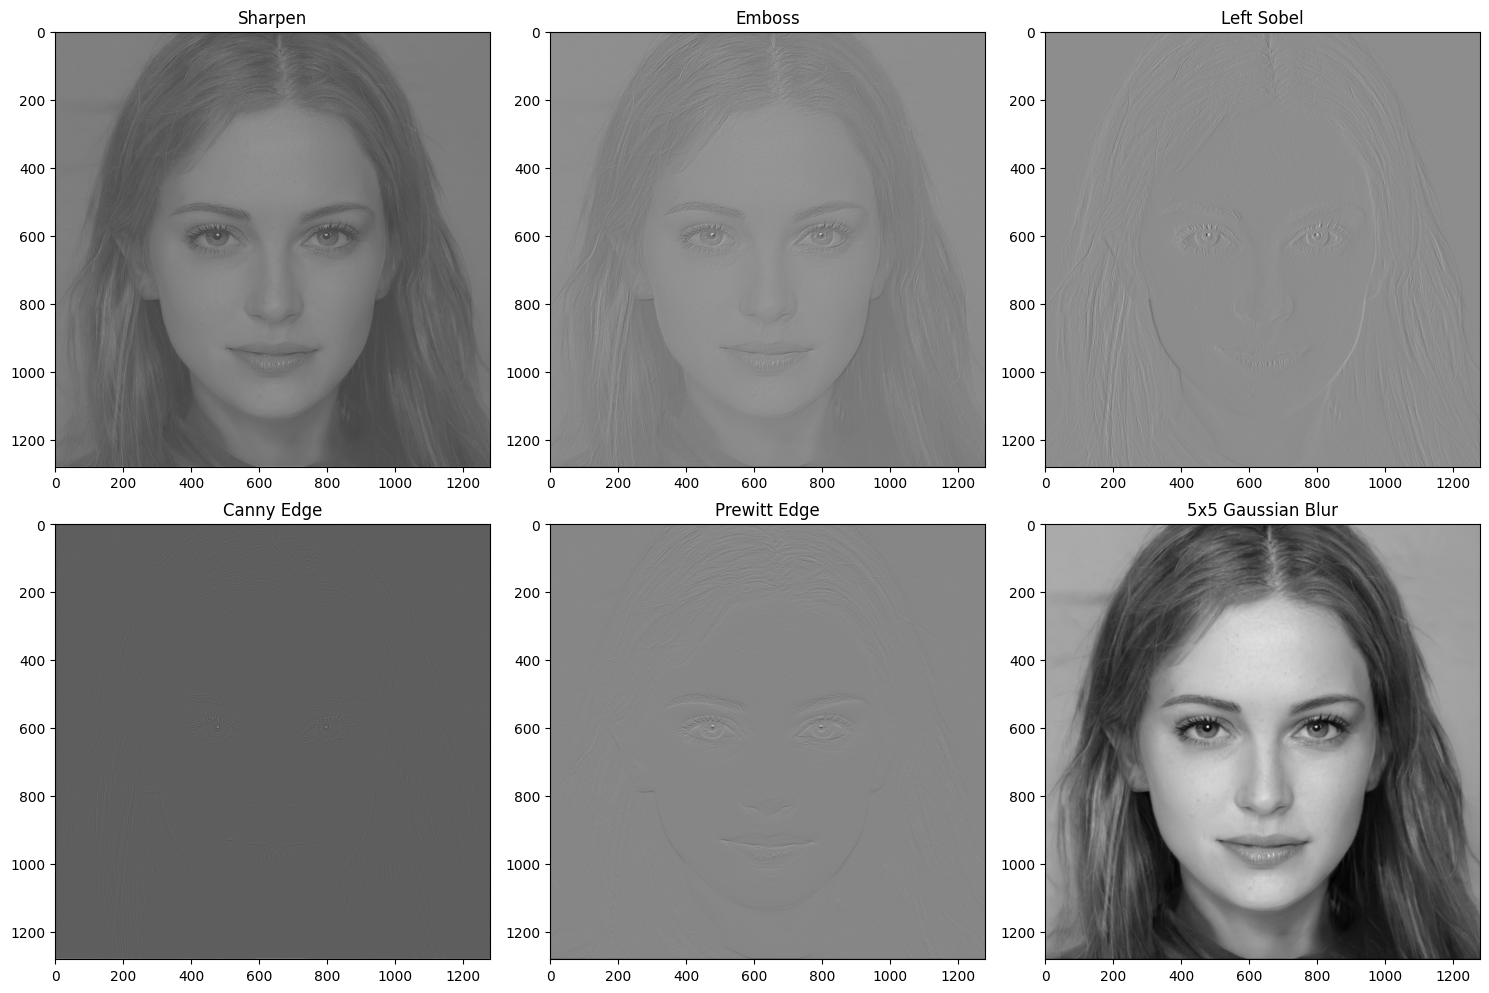

In [6]:
# Definisikan semua kernel
kernel_sharpen = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
kernel_emboss = np.array([[-2, -1, 0], [-1, 1, 1], [0, 1, 2]])
kernel_sobel = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]])
kernel_canny = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]])
kernel_prewitt = np.array([[-1,-1,-1], [0,0,0], [1,1,1]])
kernel_blur_5x5 = (1/256) * np.array([[1,4,6,4,1], [4,16,24,16,4], [6,24,36,24,6], [4,16,24,16,4], [1,4,6,4,1]])

# Terapkan setiap filter
sharpen_result = convolution2d(img_gray_female, kernel_sharpen, padding=1)
emboss_result = convolution2d(img_gray_female, kernel_emboss, padding=1)
sobel_result = convolution2d(img_gray_female, kernel_sobel, padding=1)
canny_result = convolution2d(img_gray_female, kernel_canny, padding=1)
prewitt_result = convolution2d(img_gray_female, kernel_prewitt, padding=1)
blur_5x5_result = convolution2d(img_gray_female, kernel_blur_5x5, padding=2)

# Tampilkan hasil
filters = {
    'Sharpen': sharpen_result, 'Emboss': emboss_result,
    'Left Sobel': sobel_result, 'Canny Edge': canny_result,
    'Prewitt Edge': prewitt_result, '5x5 Gaussian Blur': blur_5x5_result
}

fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs = axs.flatten()
for i, (name, img_result) in enumerate(filters.items()):
    axs[i].imshow(img_result, cmap='gray')
    axs[i].set_title(name)
plt.tight_layout()
plt.show()